## Heat Equation example (d=2)

We consider the following linear PDE problem,

\begin{equation*}
    \mathcal{L}^{\phi := a}_xu=\frac{\partial}{\partial t}u(x,t)-a\frac{\partial^2}{\partial x^2}u(x,t) = f(x,t)
\end{equation*}

we build our model in a similar fashion as in the 1d example,

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.special as sp
from sklearn.gaussian_process import GaussianProcessRegressor
from sympy import *
from physgp.kernels import PhysKerBase, PhysKerGP
from physgp.priors import SquExpKernel
from physgp.utils import obs_concat

In [2]:
L = sympify("Derivative(u, x1) - a*Derivative(u, x0, 2)")
# Where x <=> x0 and t <=> x1.

squexp = SquExpKernel(dim=2)
squexp.u_func

s**2*exp(-w0*(x0 - y0)**2/2 - w1*(x1 - y1)**2/2)

In [3]:
phys_kernel_base = PhysKerBase(lin_op=L, prior_kernel=squexp)
phys_kernel_base.kernel_expression_dict["ff"]

a*s**2*w0*w1*(2*x1 - 2*y1)*(w0*(x0 - y0)**2 - 1)*exp(-w0*(x0 - y0)**2/2 - w1*(x1 - y1)**2/2)/2 - a*s**2*w0*(-a*w0**2*(x0 - y0)**2*(w0*(x0 - y0)**2 - 1) + 4*a*w0**2*(x0 - y0)**2 + a*w0*(w0*(x0 - y0)**2 - 1) - 2*a*w0 + w0*w1*(x0 - y0)**2*(x1 - y1) - w1*(x1 - y1))*exp(-w0*(x0 - y0)**2/2 - w1*(x1 - y1)**2/2) + s**2*w1**2*(-2*x1 + 2*y1)*(2*x1 - 2*y1)*exp(-w0*(x0 - y0)**2/2 - w1*(x1 - y1)**2/2)/4 + s**2*w1*exp(-w0*(x0 - y0)**2/2 - w1*(x1 - y1)**2/2)

Now, lets generate some data via another one of the utility functions provided by physgp, gen_point_grid. Where we can specifiy the number of points in each 1-d subspace and the bounds of the hypercube along with the method for sampling the points.

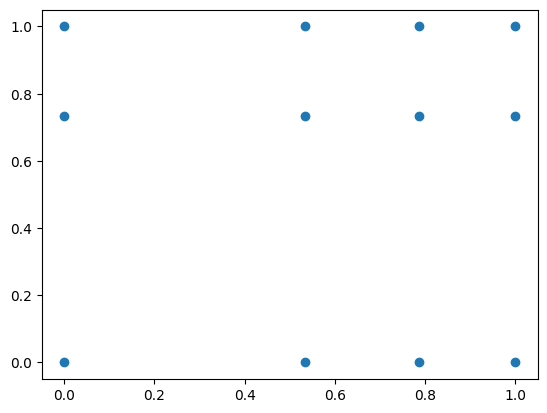

In [14]:
from physgp.utils import gen_point_grid

np.random.seed(10)
X_f = gen_point_grid([4, 3], [(0,1),(0,1)], ["random", "random"])
plt.scatter(X_f[:,0], X_f[:,1])
plt.show()

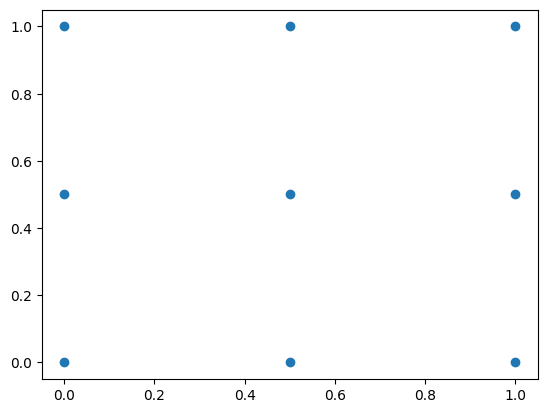

In [15]:
X_u = gen_point_grid(3, [(0,1), (0,1)], "uniform")
plt.scatter(X_u[:,0], X_u[:,1])
plt.show()

In [16]:
true_u = np.vectorize(lambda x,t : np.exp(-t)*np.sin(2*np.pi*x))
true_f = np.vectorize(lambda x,t : np.exp(-t)*(4*np.pi**2-1)*np.sin(2*np.pi*x))

data = obs_concat(X_u, X_f)
y = np.hstack((true_u(X_u[:,0], X_u[:,1]), true_f(X_f[:,0], X_f[:,1])))
y

array([ 0.00000000e+00,  1.22464680e-16, -2.44929360e-16,  0.00000000e+00,
        7.42785831e-17, -1.48557166e-16,  0.00000000e+00,  4.50522380e-17,
       -9.01044760e-17, -3.46707766e-15, -1.37992071e+01,  0.00000000e+00,
       -3.02236016e+00, -9.42449419e-15, -3.75101339e+01,  0.00000000e+00,
       -8.21562669e+00, -4.52026786e-15, -1.79909764e+01,  0.00000000e+00,
       -3.94045904e+00])

Lets now fit a GP to this data.

In [26]:
phys_kernel_gp = PhysKerGP(phys_kernel_base, 
                           {'a':1, 'w0':1, 'w1':1, 's':1},
                           {'a':(1,1), 'w0':(1e-5,200), 'w1':(1e-5,200), 's':(1,1)},
                           sigma=(0,1e-15))

gp = GaussianProcessRegressor(kernel=phys_kernel_gp,
                              alpha=1e-10,
                              n_restarts_optimizer=2)

gp.fit(data, y)

c:\Users\marku\physgp\physgp\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter s is close to the specified lower bound 1. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".","PhysKerGP(1, 1, 1, 1)"
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",2
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`Glossary

And visualise the posterior fit.

In [27]:
N_plot = 30
X, T = np.meshgrid(np.linspace(0,1,N_plot), np.linspace(0,1,N_plot))
pos = np.vstack([X.ravel(), T.ravel()]).T

u_mean_prediction, u_covariance_matrix = gp.predict(obs_concat(X_u=pos), return_cov=True)
f_mean_prediction, f_covariance_matrix = gp.predict(obs_concat(X_f=pos), return_cov=True)

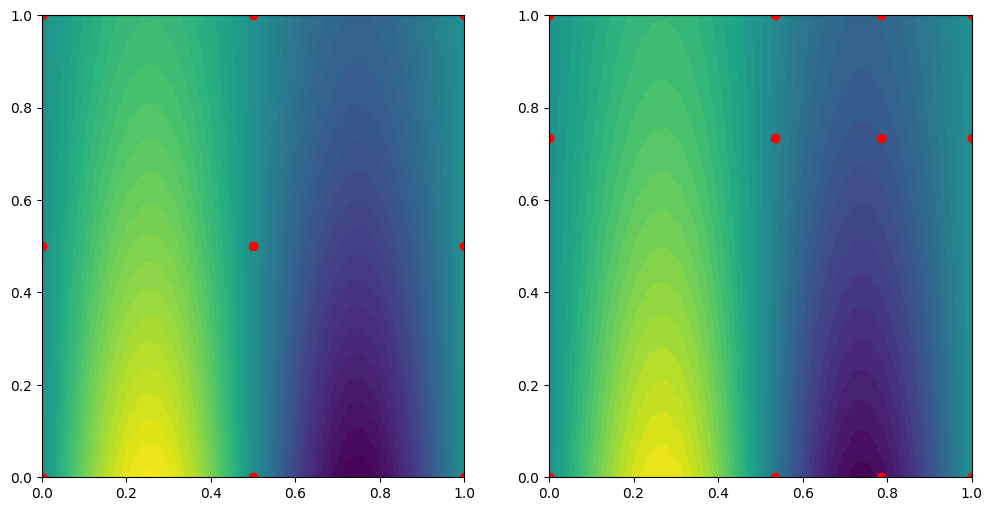

In [33]:
fig, ax = plt.subplots(1,2, figsize=(12,6))

ax[0].contourf(X, T, u_mean_prediction.reshape(N_plot, N_plot), levels=50)
ax[0].scatter(X_u[:,0], X_u[:,1], marker="o", color="red")

ax[1].contourf(X, T, f_mean_prediction.reshape(N_plot, N_plot), levels=50)
ax[1].scatter(X_f[:,0], X_f[:,1], marker="o", color="red")

plt.show()

And the absolute errors,

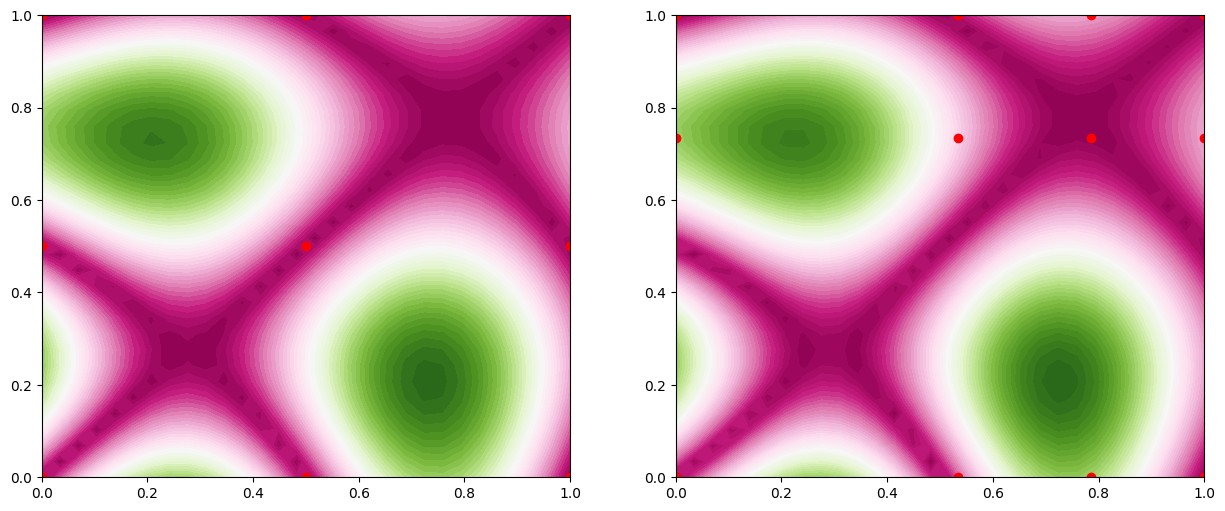

In [34]:
fig, ax = plt.subplots(1,2, figsize=(15,6))

ax[0].contourf(X, T, (abs(u_mean_prediction-true_u(pos[:,1], pos[:,0]))).reshape(N_plot, N_plot), levels=50, cmap="PiYG")
ax[0].scatter(X_u[:,0], X_u[:,1], marker="o", color="red")

ax[1].contourf(X, T, (abs(f_mean_prediction-true_f(pos[:,1], pos[:,0]))).reshape(N_plot, N_plot), levels=50, cmap="PiYG")
ax[1].scatter(X_f[:,0], X_f[:,1], marker="o", color="red")

plt.show()

One aspect of the physgp package we have not yet explored is the ability to build custom product kernels. As our domain is now 2d, now feels like a good time to show this feature.

In [5]:
from physgp.priors import PeriodicKernel, LinearKernel

# By specifying dim with a list we can choose the dimensions the kernel functions are defined on.
custom_kernel = PeriodicKernel([0]) * LinearKernel([1])
custom_kernel.u_func

s**2*(c + m*x1*y1)*exp(-2*sin(pi*(x0 - y0)/p)**2/l**2)

In [6]:
phys_kernel_base_custom = PhysKerBase(lin_op=L, prior_kernel=custom_kernel)
phys_kernel_base_custom.kernel_expression_dict["ff"]

-4*pi**2*a*m*s**2*y1*(sin(pi*(x0 - y0)/p)**2 - cos(pi*(x0 - y0)/p)**2 + 4*sin(pi*(x0 - y0)/p)**2*cos(pi*(x0 - y0)/p)**2/l**2)*exp(-2*sin(pi*(x0 - y0)/p)**2/l**2)/(l**2*p**2) - 4*pi**2*a*s**2*(-4*pi**2*a*(c + m*x1*y1)*(-sin(pi*(x0 - y0)/p)**2 + cos(pi*(x0 - y0)/p)**2 + 2*sin(pi*(x0 - y0)/p)**4/l**2 - 12*sin(pi*(x0 - y0)/p)**2*cos(pi*(x0 - y0)/p)**2/l**2 + 2*cos(pi*(x0 - y0)/p)**4/l**2)/p**2 + 32*pi**2*a*(c + m*x1*y1)*(1 - 2*sin(pi*(x0 - y0)/p)**2/l**2 + 2*cos(pi*(x0 - y0)/p)**2/l**2)*sin(pi*(x0 - y0)/p)**2*cos(pi*(x0 - y0)/p)**2/(l**2*p**2) - 4*pi**2*a*(c + m*x1*y1)*(sin(pi*(x0 - y0)/p)**2 - cos(pi*(x0 - y0)/p)**2 + 4*sin(pi*(x0 - y0)/p)**2*cos(pi*(x0 - y0)/p)**2/l**2)*sin(pi*(x0 - y0)/p)**2/(l**2*p**2) + 4*pi**2*a*(c + m*x1*y1)*(sin(pi*(x0 - y0)/p)**2 - cos(pi*(x0 - y0)/p)**2 + 4*sin(pi*(x0 - y0)/p)**2*cos(pi*(x0 - y0)/p)**2/l**2)*cos(pi*(x0 - y0)/p)**2/(l**2*p**2) - 16*pi**2*a*(c + m*x1*y1)*(sin(pi*(x0 - y0)/p)**2 - cos(pi*(x0 - y0)/p)**2 + 4*sin(pi*(x0 - y0)/p)**2*cos(pi*(x0 - y0)/p)

In [7]:
phys_kernel_base_custom.params_to_specify

[s, l, c, p, m, a]

Let's fit this model on the same set of data.

In [17]:
phys_kernel_gp_custom = PhysKerGP(phys_kernel_base_custom, 
                           {'a':1, 'l':1, 'c':1, 'p':1, 'm':1, 's':1},
                           {'a':(1,1), 'l':(1e-5,200), 'c':(1e-5,200), 'p':(1e-5,200), 'm':(1e-5,200), 's':(1,1)},
                           sigma=(0,1e-15))

gp_custom = GaussianProcessRegressor(kernel=phys_kernel_gp_custom,
                              alpha=1e-10,
                              n_restarts_optimizer=2)

gp_custom.fit(data, y)

c:\Users\marku\physgp\physgp\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter s is close to the specified lower bound 1. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".","PhysKerGP(1, 1, 1, 1, 1, 1)"
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",2
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`Gl

And now we can produce a visualisation of the posterior once again.

In [18]:
N_plot = 30
X, T = np.meshgrid(np.linspace(0,1,N_plot), np.linspace(0,1,N_plot))
pos = np.vstack([X.ravel(), T.ravel()]).T

u_mean_prediction, u_covariance_matrix = gp_custom.predict(obs_concat(X_u=pos), return_cov=True)
f_mean_prediction, f_covariance_matrix = gp_custom.predict(obs_concat(X_f=pos), return_cov=True)

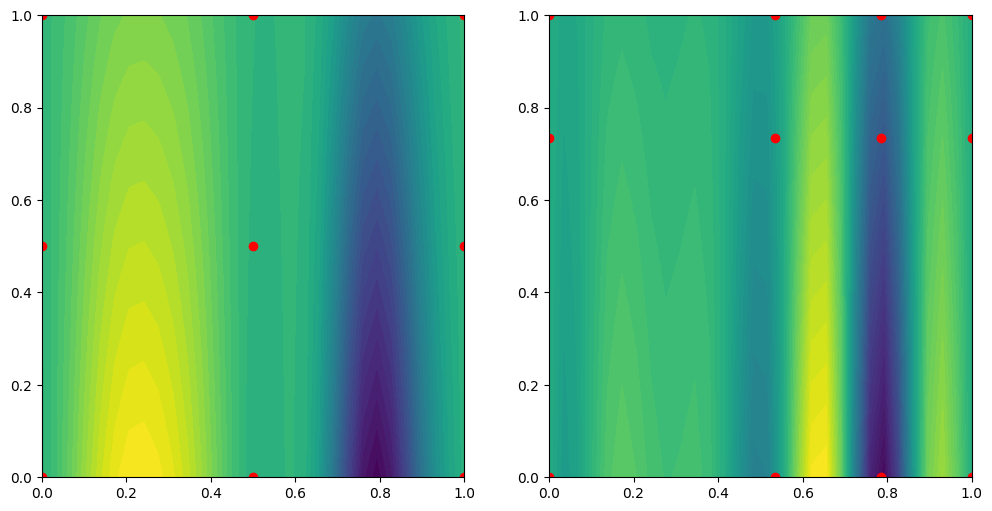

In [19]:
fig, ax = plt.subplots(1,2, figsize=(12,6))

ax[0].contourf(X, T, u_mean_prediction.reshape(N_plot, N_plot), levels=50)
ax[0].scatter(X_u[:,0], X_u[:,1], marker="o", color="red")

ax[1].contourf(X, T, f_mean_prediction.reshape(N_plot, N_plot), levels=50)
ax[1].scatter(X_f[:,0], X_f[:,1], marker="o", color="red")

plt.show()

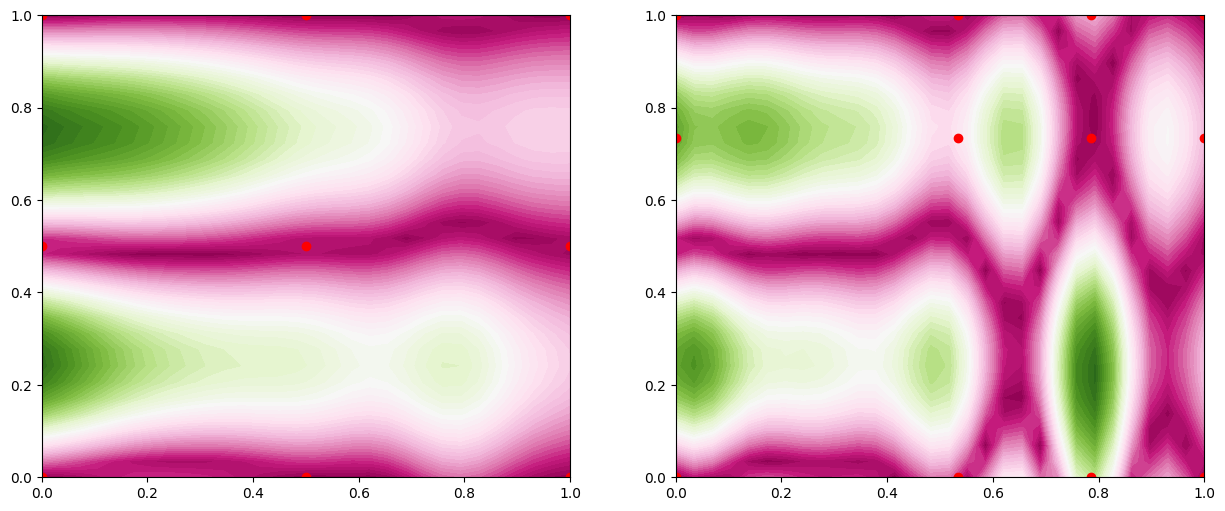

In [20]:
fig, ax = plt.subplots(1,2, figsize=(15,6))

ax[0].contourf(X, T, (abs(u_mean_prediction-true_u(pos[:,1], pos[:,0]))).reshape(N_plot, N_plot), levels=50, cmap="PiYG")
ax[0].scatter(X_u[:,0], X_u[:,1], marker="o", color="red")

ax[1].contourf(X, T, (abs(f_mean_prediction-true_f(pos[:,1], pos[:,0]))).reshape(N_plot, N_plot), levels=50, cmap="PiYG")
ax[1].scatter(X_f[:,0], X_f[:,1], marker="o", color="red")

plt.show()